In [1]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import polars as pl
import numpy as np
import optuna
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import math

In [2]:
from pathlib import Path
path = Path.cwd()
if not Path(path, "data").exists(): path = path.parent

In [3]:
df_train = pl.read_parquet(path / "data" / "train_tip.parquet")
df_val = pl.read_parquet(path / "data" / "val_tip.parquet")
df_test = pl.read_parquet(path / "data" / "test_tip.parquet")

In [4]:
df_train.collect_schema()

Schema([('PULocationID', Int16),
        ('DOLocationID', Int16),
        ('tip_amount', Int16),
        ('payment_type', Int8),
        ('VendorID', Int8),
        ('pickup_latitude', Float64),
        ('pickup_longitude', Float64),
        ('dropoff_latitude', Float64),
        ('dropoff_longitude', Float64),
        ('pickup_dist_nyc', Float64),
        ('dropoff_dist_nyc', Float64),
        ('pickup_dist_chp', Float64),
        ('dropoff_dist_chp', Float64),
        ('pickup_dist_exp', Float64),
        ('dropoff_dist_exp', Float64),
        ('distance', Float64),
        ('direction', Float64),
        ('month', Int8),
        ('dayofyear', Int16),
        ('weekday', Int8),
        ('hour', Float64),
        ('trip_duration_min', Int64),
        ('adj_dist', Float64),
        ('diff_eta', Float64),
        ('delay_ratio', Float64)])

In [5]:
class TaxiTipMDN(nn.Module):
    def __init__(self, num_numeric, cat_vocab_sizes, num_gaussians=5):
        super(TaxiTipMDN, self).__init__()
        self.num_gaussians = num_gaussians
        
        # --- 1. CAPA DE ESCALADO (StandardScaler Integrado) ---
        # Registramos buffers (no se entrenan, pero se guardan con el modelo)
        self.register_buffer('num_mean', torch.zeros(num_numeric))
        self.register_buffer('num_std', torch.ones(num_numeric))
        
        # --- 2. CAPAS DE EMBEDDING PARA CATEGÓRICAS ---
        self.embeddings = nn.ModuleDict({
            name: nn.Embedding(num_embeddings=vocab_size, embedding_dim=min(50, (vocab_size + 1) // 2))
            for name, vocab_size in cat_vocab_sizes.items()
        })
        
        # Calculamos cuántas características entran a la red principal:
        # Numéricas + (4 temporales * 2 sen/cos = 8) + suma de dimensiones de embeddings
        emb_out_dim = sum(emb.embedding_dim for emb in self.embeddings.values())
        input_dim = num_numeric + 8 + emb_out_dim
        
        # --- 3. RED NEURONAL PRINCIPAL (Backbone MLP) ---
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128), # Estabiliza el entrenamiento
            nn.GELU(),           # Mejor que ReLU
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Dropout(0.2)
        )
        
        # --- 4. CABEZAS DE LA MDN (Las "Montañitas") ---
        # pi: Probabilidad de cada montañita (K valores)
        self.z_pi = nn.Linear(64, num_gaussians)
        # mu: El centro (media) de cada montañita (K valores)
        self.z_mu = nn.Linear(64, num_gaussians)
        # sigma: La anchura (desviación estándar) de cada montañita (K valores)
        self.z_sigma = nn.Linear(64, num_gaussians)

        self._initialize_weights()

    def _initialize_weights(self):
        """Fuerza a las gaussianas a nacer separadas para evitar Mode Collapse"""
        # esparcimos los centros (mu) entre 0$ y 100$
        mu_init = torch.linspace(0, 1000, self.num_gaussians)
        
        # Inyectamos estos centros en el 'bias' de la capa mu
        self.z_mu.bias.data.copy_(mu_init)
        
        # Hacemos que la red arranque con un poco más de incertidumbre (sigmas más anchas)
        # Esto evita que cree picos de aguja demasiado pronto
        self.z_sigma.bias.data.fill_(1.0)

    def set_scaler_stats(self, means, stds):
        """Método para inyectarle las medias y stds de Train antes de entrenar"""
        self.num_mean.copy_(torch.tensor(means, dtype=torch.float32))
        self.num_std.copy_(torch.tensor(stds, dtype=torch.float32))

    def temporal_sin_cos(self, x_temp):
        """Convierte (month, dayofyear, weekday, hour) en senos y cosenos"""
        # Constantes máximas para cada variable temporal
        max_vals = torch.tensor([12.0, 366.0, 7.0, 24.0], device=x_temp.device)
        
        # Transformación circular
        scaled = (x_temp * 2 * math.pi) / max_vals
        sin_cols = torch.sin(scaled)
        cos_cols = torch.cos(scaled)
        
        # Devolvemos 8 columnas (4 senos, 4 cosenos intercalados o concatenados)
        return torch.cat([sin_cols, cos_cols], dim=1)

    def forward(self, x_num, x_cat, x_temp):
        # 1. Escalar numéricas usando los buffers estáticos
        x_num_scaled = (x_num - self.num_mean) / (self.num_std + 1e-7)
        
        # 2. Transformar temporales a sen/cos
        x_temp_enc = self.temporal_sin_cos(x_temp)
        
        # 3. Procesar Embeddings
        # Asumimos que x_cat es un diccionario con tensores de enteros
        emb_outs = []
        for name, emb_layer in self.embeddings.items():
            emb_outs.append(emb_layer(x_cat[name]))
        x_cat_enc = torch.cat(emb_outs, dim=1)
        
        # 4. Concatenar todo (El vector de características final)
        x_combined = torch.cat([x_num_scaled, x_temp_enc, x_cat_enc], dim=1)
        
        # 5. Pasar por la red principal
        hidden = self.mlp(x_combined)
        
        # 6. Salidas de la MDN
        pi = F.softmax(self.z_pi(hidden), dim=-1) # Las probabilidades deben sumar 1
        mu = self.z_mu(hidden)
        # Usamos softplus + un epsilon pequeñito para evitar sigmas = 0 (colapso matemático)
        sigma = F.softplus(self.z_sigma(hidden)) + 1e-6 
        
        return pi, mu, sigma

In [6]:
def mdn_loss_function(pi, mu, sigma, target):
    """
    pi, mu, sigma: Salidas del modelo [batch_size, num_gaussians]
    target: Propina real [batch_size, 1]
    """
    target = target.expand_as(mu)
    
    normal_log_prob = -0.5 * ((target - mu) / sigma) ** 2 - torch.log(sigma) - 0.5 * math.log(2 * math.pi)
    
    log_pi = torch.log(pi + 1e-8)
    log_component_probs = log_pi + normal_log_prob
    
    log_prob_total = torch.logsumexp(log_component_probs, dim=1)
    
    return -torch.mean(log_prob_total)

In [7]:
# --- PREPARACIÓN ---
# variables Numéricas (16 columnas) -> Irán al StandardScaler interno
num_cols = [
    'pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude',
    'pickup_dist_nyc', 'dropoff_dist_nyc', 'pickup_dist_chp', 'dropoff_dist_chp',
    'pickup_dist_exp', 'dropoff_dist_exp', 'distance', 'direction',
    'trip_duration_min', 'adj_dist', 'diff_eta', 'delay_ratio'
]

# variables Categóricas (4 columnas) -> Irán a las capas de Embedding
vocab_sizes = {'PULocationID': 264, 'DOLocationID': 264, 'payment_type': 8, 'VendorID': 5}
cat_cols = list(vocab_sizes.keys())

# variables Temporales (4 columnas) -> Irán a la transformación Seno/Coseno
temp_cols = ['month', 'dayofyear', 'weekday', 'hour']

# variable Objetivo
target_col = ['tip_amount']


medias_train = df_train.select(num_cols).mean().to_numpy()[0]
stds_train = df_train.select(num_cols).std().to_numpy()[0]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modelo = TaxiTipMDN(num_numeric=16, cat_vocab_sizes=vocab_sizes, num_gaussians=5)
modelo.set_scaler_stats(medias_train, stds_train)
modelo = modelo.to(device)

# Optimizador (AdamW funciona genial con MDNs)
optimizer = torch.optim.AdamW(modelo.parameters(), lr=0.001, weight_decay=0.01)

# --- BUCLE DE ENTRENAMIENTO ---

# subimos todo a la gráfica de golpe (como tensores individuales)
x_num_gpu = torch.tensor(df_train.select(num_cols).to_numpy(), dtype=torch.float32, device=device)
x_temp_gpu = torch.tensor(df_train.select(temp_cols).to_numpy(), dtype=torch.float32, device=device)
target_gpu = torch.tensor(df_train.select(target_col).to_numpy(), dtype=torch.float32, device=device)

cat_data_gpu = {
    col: torch.tensor(df_train[col].to_numpy(), dtype=torch.long, device=device)
    for col in cat_cols
}

dataset_size = len(target_gpu)
batch_size = 32768 # ¡Ahora puedes subirlo incluso a 65536 o 131072!

print("Iniciando entrenamiento...")

num_epochs = 30
for epoch in range(num_epochs):
    modelo.train()
    total_loss = 0.0
    
    # Mezclamos los índices en la propia GPU¡
    indices = torch.randperm(dataset_size, device=device)
    
    # Extraemos bloques enteros matemáticamente
    for start_idx in range(0, dataset_size, batch_size):
        
        # Sacamos los índices de este lote
        batch_idx = indices[start_idx : start_idx + batch_size]
        
        # Filtramos todos los tensores de golpe (slicing masivo)
        b_num = x_num_gpu[batch_idx]
        b_temp = x_temp_gpu[batch_idx]
        b_target = target_gpu[batch_idx]
        b_cat = {col: cat_data_gpu[col][batch_idx] for col in cat_cols}
        
        # Forward pass y Backpropagation normal
        optimizer.zero_grad()
        pi, mu, sigma = modelo(b_num, b_cat, b_temp)
        loss = mdn_loss_function(pi, mu, sigma, b_target)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(modelo.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        
    avg_loss = total_loss / (dataset_size / batch_size)
    print(f"Época [{epoch+1}/{num_epochs}] | Loss (NLL): {avg_loss:.4f}")

Iniciando entrenamiento...
Época [1/30] | Loss (NLL): 215.4551
Época [2/30] | Loss (NLL): 7.3012
Época [3/30] | Loss (NLL): 5.6187
Época [4/30] | Loss (NLL): 5.1553
Época [5/30] | Loss (NLL): 4.7058
Época [6/30] | Loss (NLL): 4.0018
Época [7/30] | Loss (NLL): 2.9359
Época [8/30] | Loss (NLL): 1.8243
Época [9/30] | Loss (NLL): 1.5555
Época [10/30] | Loss (NLL): 1.4489
Época [11/30] | Loss (NLL): 1.3494
Época [12/30] | Loss (NLL): 1.2575
Época [13/30] | Loss (NLL): 1.1488
Época [14/30] | Loss (NLL): 1.0152
Época [15/30] | Loss (NLL): 0.8744
Época [16/30] | Loss (NLL): 1.1016
Época [17/30] | Loss (NLL): 0.4892
Época [18/30] | Loss (NLL): 0.3721
Época [19/30] | Loss (NLL): 0.2612
Época [20/30] | Loss (NLL): 0.1579
Época [21/30] | Loss (NLL): 0.0470
Época [22/30] | Loss (NLL): -0.0516
Época [23/30] | Loss (NLL): -0.1369
Época [24/30] | Loss (NLL): -0.2405
Época [25/30] | Loss (NLL): -0.3186
Época [26/30] | Loss (NLL): -0.3416
Época [27/30] | Loss (NLL): -0.1385
Época [28/30] | Loss (NLL): -

Viajes encontrados con propina > 3$: 105750


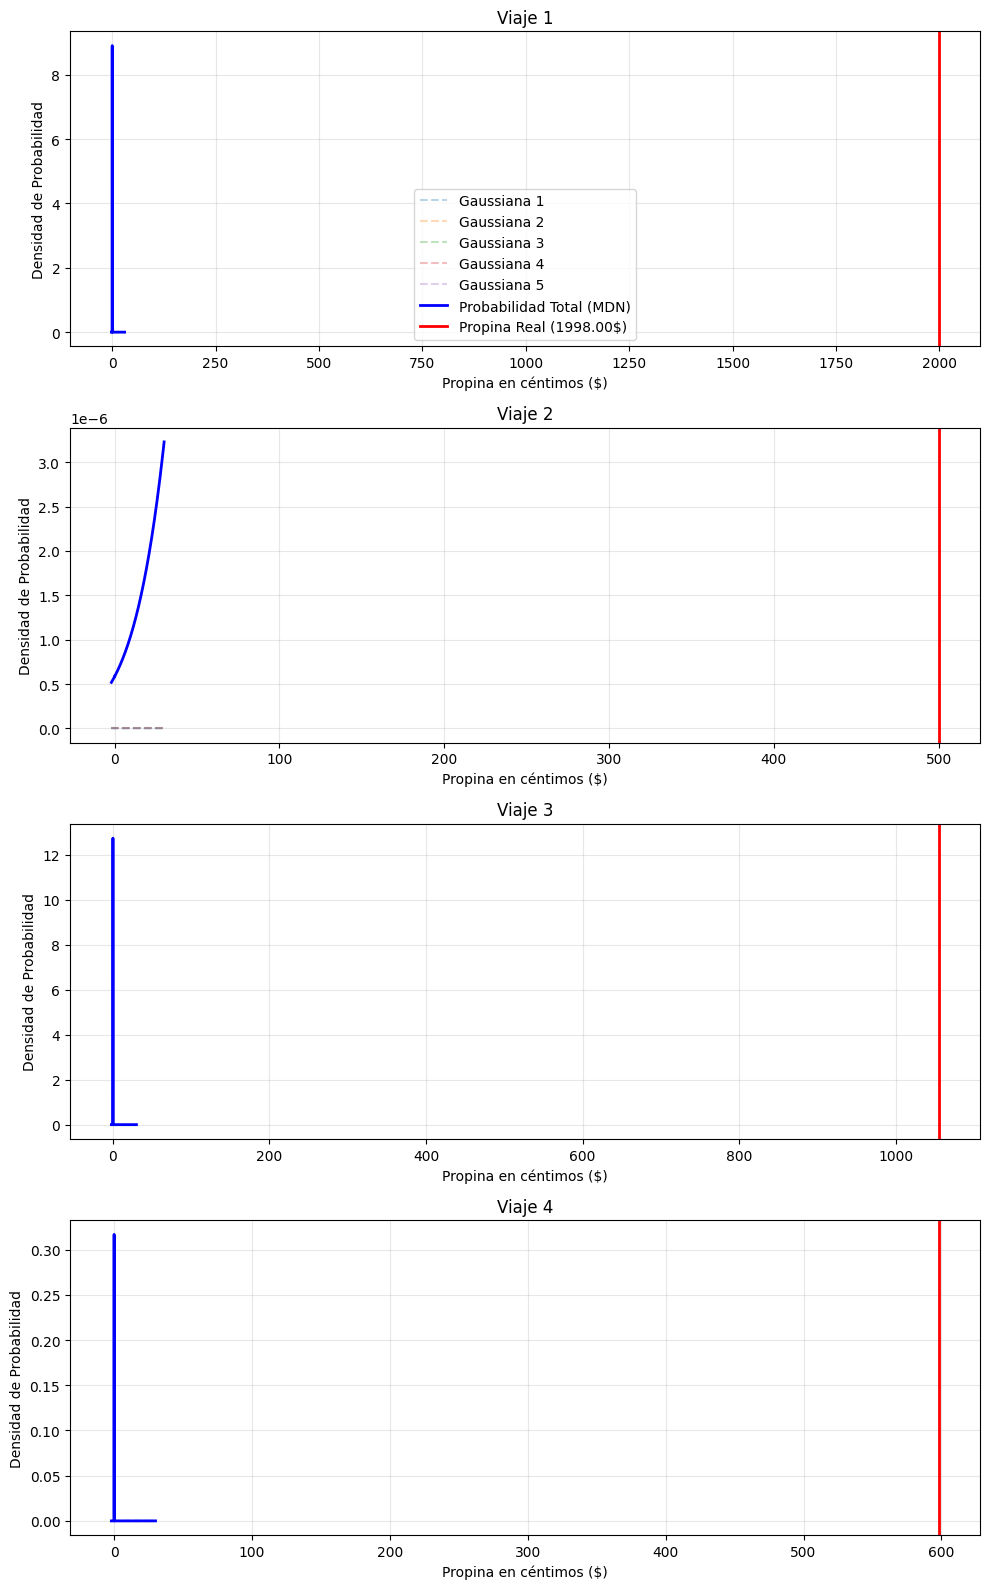

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def plot_mdn_predictions(modelo, b_num, b_cat, b_temp, b_target, num_samples=3):
    modelo.eval()
    with torch.no_grad():
        pi, mu, sigma = modelo(b_num, b_cat, b_temp)
    
    # Pasamos a CPU y numpy para plotear
    pi = pi.cpu().numpy()
    mu = mu.cpu().numpy()
    sigma = sigma.cpu().numpy()
    targets = b_target.cpu().numpy()
    
    fig, axes = plt.subplots(num_samples, 1, figsize=(10, 4 * num_samples))
    if num_samples == 1: axes = [axes]
    
    # Eje X en dólares (ej: de 0$ a 30$)
    x_axis = np.linspace(-2, 30, 1000)
    
    for i in range(num_samples):
        ax = axes[i]
        total_pdf = np.zeros_like(x_axis)
        
        # Dibujamos cada una de las 5 gaussianas y las sumamos
        for k in range(pi.shape[1]):
            # La fórmula de la montaña: Probabilidad de la montaña * Distribución Normal
            pdf_k = pi[i, k] * norm.pdf(x_axis, mu[i, k], sigma[i, k])
            total_pdf += pdf_k
            
            # Dibujamos la montaña individual en gris clarito
            ax.plot(x_axis, pdf_k, '--', alpha=0.3, label=f'Gaussiana {k+1}' if i==0 else "")
            
        # Dibujamos la mezcla total en azul fuerte
        ax.plot(x_axis, total_pdf, color='blue', lw=2, label='Probabilidad Total (MDN)' if i==0 else "")
        
        # Marcamos con una línea roja la propina REAL que dejó el pasajero
        ax.axvline(targets[i][0], color='red', linestyle='-', lw=2, label=f'Propina Real ({targets[i][0]:.2f}$)')
        
        ax.set_title(f'Viaje {i+1}')
        ax.set_xlabel('Propina en céntimos ($)')
        ax.set_ylabel('Densidad de Probabilidad')
        if i == 0: ax.legend()
        ax.grid(alpha=0.3)
        
    plt.tight_layout()
    plt.show()

x_num_test = torch.tensor(df_test.select(num_cols).to_numpy(), dtype=torch.float32, device=device)
x_temp_test = torch.tensor(df_test.select(temp_cols).to_numpy(), dtype=torch.float32, device=device)
target_test = torch.tensor(df_test.select(target_col).to_numpy(), dtype=torch.float32, device=device)
cat_data_test = {col: torch.tensor(df_test[col].to_numpy(), dtype=torch.long, device=device) for col in cat_cols}


mascara_propinas = (target_test.squeeze() > 300)

x_num_con_propina = x_num_test[mascara_propinas]
x_temp_con_propina = x_temp_test[mascara_propinas]
target_con_propina = target_test[mascara_propinas]

cat_con_propina = {
    col: tensor[mascara_propinas] 
    for col, tensor in cat_data_test.items()
}

print(f"Viajes encontrados con propina > 3$: {len(target_con_propina)}")

plot_mdn_predictions(
    modelo, 
    x_num_con_propina[:4], 
    {k: v[:4] for k, v in cat_con_propina.items()}, 
    x_temp_con_propina[:4], 
    target_con_propina[:4],
    num_samples=4
)